# Regression Model For Respiratory Disease Deaths

**MATH 189 Final Project**

Group Members: Kevin Jacob, Amelia Oo, Henry Liu, Christian Kumagai

## Problem Statement

Air pollution is widely linked to respiratory health problems, but the strength of that relationship can vary across location and over time. In this project, we examine whether county-level air quality indicators are statistically associated with respiratory disease mortality in the United States. Our proposal focuses on combining environmental data with health data to explore whether patterns in air quality correspond to patterns in respiratory mortality. 

This question is relevant because air quality affects large populations and can differ significantly between counties. If certain pollution measures correspond to respiratory mortality, the relationship may highlight broader environmental health patterns. From a statistical perspective, this project also presents challenges because it requires merging datasets from different sources and evaluating how multiple pollution-related variables relate to health outcomes over time. 


## Initial Dataset

### Dataset Sources
- **CDC Wonder:** obtained yearly death counts due to respiratory illness per county
- **EPA Air Quality System:** obtained annual air quality data per county

### Processing Overview
All processing code can be found in the `data.py` file. 
- Concatenate EPA data from 2018 to 2024
- Remove rows with missing values
- Map CDC dataset county format to match EPA dataset county format
- Join datasets on State, County, and Year
- 
    Our initial dataset processing involved downloading datasets from the EPA’s Air Quality System for annual air quality data by county. As mentioned above, we are using data from 2018 through 2024. We also downloaded a dataset from CDC Wonder containing information about the counts of death due to respiratory illness as that was our health problem of interest. The dataset downloading can be seen in the data.py file which also includes some of the initial processing. The processing program starts by concatenating all the EPA datasets as we had a separate dataset for each year. It then processes any potential missing values that aren’t in the dataset by removing those rows and mapping the County format in CDC dataset to match the EPA dataset. After that, the EPA dataset is joined (State, County, and Year) with the CDC dataset and the unused columns are dropped before being saved as a csv. 

### Processed Dataset
Our initial processed dataset (before any additional variable transformations) contains the following values
- **State:** State in the US that the death count was recorded
- **County:** County in the US that the count was recorded
- **Year:** Year that the death count was recorded 
- **Days with AQI:** Total number of days in the year for which an Air Quality Index (AQI) value was reported for the county
- **Good Days:** Number of days where AQI values fell within the “Good” category (AQI 0–50)
- **Moderate Days:** Number of days where AQI values fell within the “Moderate” category (AQI 51–100)
- **Unhealthy for Sensitive Group Days:** Number of days where AQI values fell within the “Unhealthy for Sensitive Groups” category (AQI 101–150)
- **Unhealthy Days:** Number of days where AQI values fell within the “Unhealthy” category (AQI 151–200)
- **Very Unhealthy Days:** Number of days where AQI values fell within the “Very Unhealthy” category (AQI 201–300)
- **Hazardous Days:** Number of days where AQI values fell within the “Hazardous” category (AQI 301+)
- **Max AQI:** Highest AQI recorded in county for given year
- **99th Percentile AQI:** 99th percentile of recorded AQI for given county/year
- **Median AQI:** Median AQI recorded for given county/year
- **Days CO:** Number of days where carbon monoxide was primary pollutant for AQI value
- **Days NO2:** Number of days where nitrogen dioxide was primary pollutant for AQI value
- **Days Ozone:** Number of days where ozone was primary pollutant for AQI value
- **Days PM2.5:** Number of days where fine particle matter was primary pollutant for AQI value
- **Days PM10:** Number of days where coarse particle matter was primary pollutant for AQI value
- **Deaths:** Total number of deaths recorded for specific cause in county/year
- **Population:** Estimated population of county in given year
- **Crude Rate:** Death rate per 100,000 in county for given year due to cause
- **Cause:** Underlying cause of death (in our case always respiratory disease)

In [1]:
import pandas as pd
import matplotlib.pyplot  as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant
import statsmodels.formula.api as smf
import numpy as np
from sklearn import metrics
from statsmodels.tsa.stattools import acf
from utils import backward
from utils import criterion

In [2]:
# Load the cleaned dataset
df = pd.read_csv("./datasets/processed_dataset.csv")
df.columns = df.columns.str.replace(" ", "_")
df.columns = df.columns.str.replace(".", "_")
df["State"] = df["State"].astype('category')
df["County"] = df["County"].astype('category')

# Preview the data
df.head()

,State,County,Year,Days_with_AQI,Good_Days,Moderate_Days,Unhealthy_for_Sensitive_Groups_Days,Unhealthy_Days,Very_Unhealthy_Days,Hazardous_Days,...,Median_AQI,Days_CO,Days_NO2,Days_Ozone,Days_PM2_5,Days_PM10,Deaths,Population,Crude_Rate,Cause
0,Alabama,Baldwin,2018,270,232,38,0,0,0,0,...,37,0,0,194,76,0,225.0,218022.0,103.2,respiratory_diseases
1,Alabama,Clay,2018,110,86,24,0,0,0,0,...,36,0,0,0,110,0,24.0,13275.0,180.8,respiratory_diseases
2,Alabama,Colbert,2018,277,235,42,0,0,0,0,...,37,0,0,184,93,0,97.0,54762.0,177.1,respiratory_diseases
3,Alabama,DeKalb,2018,350,302,48,0,0,0,0,...,36,0,0,286,64,0,111.0,71385.0,155.5,respiratory_diseases
4,Alabama,Elmore,2018,222,203,19,0,0,0,0,...,33,0,0,222,0,0,93.0,81887.0,113.6,respiratory_diseases


In [3]:
# Check the variables
df.dtypes

State                                  category
County                                 category
Year                                      int64
Days_with_AQI                             int64
Good_Days                                 int64
Moderate_Days                             int64
Unhealthy_for_Sensitive_Groups_Days       int64
Unhealthy_Days                            int64
Very_Unhealthy_Days                       int64
Hazardous_Days                            int64
Max_AQI                                   int64
90th_Percentile_AQI                       int64
Median_AQI                                int64
Days_CO                                   int64
Days_NO2                                  int64
Days_Ozone                                int64
Days_PM2_5                                int64
Days_PM10                                 int64
Deaths                                  float64
Population                              float64
Crude_Rate                              

## Dataset Analysis

In [4]:
df.describe()

,Year,Days_with_AQI,Good_Days,Moderate_Days,Unhealthy_for_Sensitive_Groups_Days,Unhealthy_Days,Very_Unhealthy_Days,Hazardous_Days,Max_AQI,90th_Percentile_AQI,Median_AQI,Days_CO,Days_NO2,Days_Ozone,Days_PM2_5,Days_PM10,Deaths,Population,Crude_Rate
count,6198.000000,6198.000000,6198.000000,6198.000000,6198.000000,6198.000000,6198.000000,6198.000000,6198.000000,6198.000000,6198.000000,6198.000000,6198.000000,6198.000000,6198.000000,6198.000000,6198.000000,6.174000e+03,6174.000000
mean,2020.977412,329.594385,237.126008,87.907067,3.461439,0.845434,0.182156,0.072281,129.635528,60.445466,40.344789,0.178767,3.088416,161.974992,154.766538,9.585673,211.740239,2.909888e+05,100.254049
std,2.003581,67.710547,70.661562,63.380046,8.670397,3.618349,1.601665,0.706093,143.063217,15.279564,9.668227,5.172511,20.844846,114.364321,123.466126,43.834727,338.232477,5.832741e+05,40.316302
min,2018.000000,7.000000,4.000000,0.000000,0.000000,0.000000,0.000000,0.000000,14.000000,7.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,10.000000,4.074000e+03,20.500000
25%,2019.000000,342.000000,199.000000,32.000000,0.000000,0.000000,0.000000,0.000000,87.000000,52.000000,36.000000,0.000000,0.000000,75.000000,5.000000,0.000000,48.000000,4.338825e+04,69.900000
50%,2021.000000,363.000000,239.000000,79.000000,1.000000,0.000000,0.000000,0.000000,106.000000,59.000000,41.000000,0.000000,0.000000,161.000000,162.000000,0.000000,109.000000,1.142910e+05,94.600000
75%,2023.000000,365.000000,290.000000,132.000000,3.000000,0.000000,0.000000,0.000000,142.000000,66.000000,45.000000,0.000000,0.000000,243.000000,251.000000,0.000000,238.000000,2.979085e+05,124.300000
max,2024.000000,366.000000,365.000000,302.000000,109.000000,69.000000,75.000000,31.000000,8368.000000,216.000000,122.000000,259.000000,365.000000,366.000000,366.000000,366.000000,5887.000000,1.010552e+07,305.400000


### Remove Columns
We can remove the `Cause` columns since all rows contain death info related to respiratory diseases as that is the focus of our project. We can also remove `Days with AQI` since the column is the sum of the different day counts meaning we have perfect multicollinearity.  `Good_Days`/`Moderate_Days` will also be removed due to multicollinarity as the different day counts will add up to the number of days in a year. This allows the remaining Days values to represent impact on mortality relative to a low pollution day.

In [5]:
df = df.drop(columns=["Cause", "Crude_Rate", "Days_with_AQI", "Good_Days", "Moderate_Days"])

### Transform Targets
Based on the column statistics above, we can see significant right skew for `Deaths` based on difference between mean and median. We can log transform the target variable to help address the skew since having skew in our targets can skew the residuals violating the assumptions of the linear regression model.

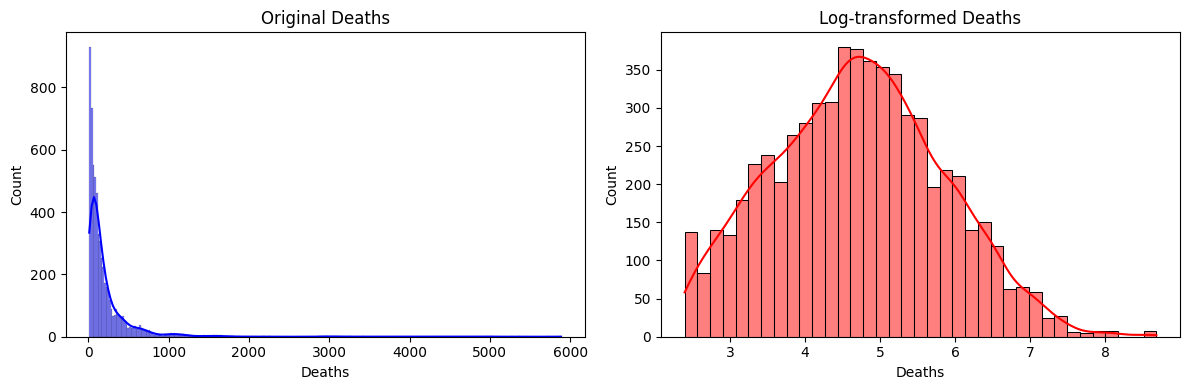

In [6]:
targets = ["Deaths"]

for col in targets:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    
    # Original distribution
    sns.histplot(df[col], kde=True, ax=axes[0], color='blue')
    axes[0].set_title(f"Original {col}")
    
    # Log transform
    df[col] = np.log1p(df[col])

    # Log transformed distribution
    sns.histplot(df[col], kde=True, ax=axes[1], color='red')
    axes[1].set_title(f"Log-transformed {col}")
    
    plt.tight_layout()
    plt.show()

### Transform Features
Based on the column stats we can see that `Max AQI` and `Population` demonstrate significant right skew so we can also apply a log transformation to limit the effect of extreme values.

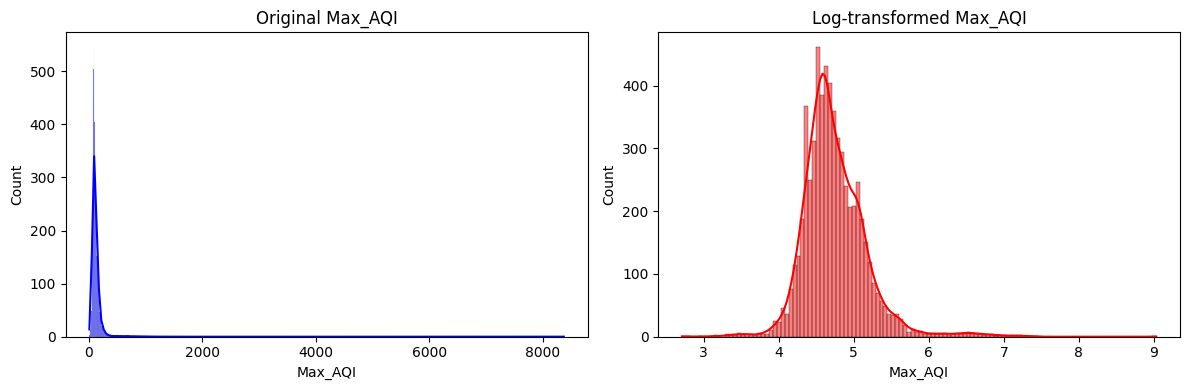

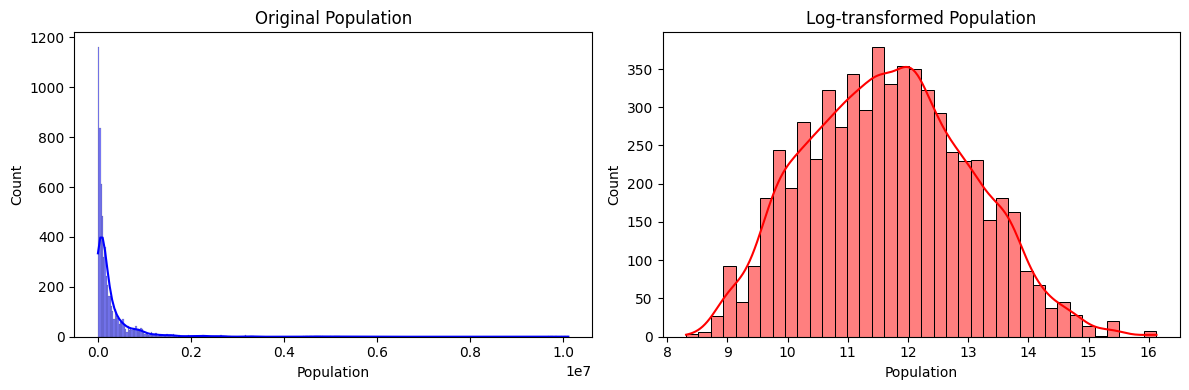

In [7]:
covariates = ["Max_AQI", "Population"]

for col in covariates:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    
    # Original distribution
    sns.histplot(df[col], kde=True, ax=axes[0], color='blue')
    axes[0].set_title(f"Original {col}")
    
    # Log transform
    df[col] = np.log1p(df[col])

    # Log transformed distribution
    sns.histplot(df[col], kde=True, ax=axes[1], color='red')
    axes[1].set_title(f"Log-transformed {col}")
    
    plt.tight_layout()
    plt.show()

Based on the column stats, there appears to be significant zero inflation meaning that many of the values are 0. If we look at `Unhealthy Days`, `Very Unhealthy Days`, `Hazardous Days`, `Days CO`, `Days NO2`, and `Days PM10` they have a 75% value of 0 indicating significant zero inflation. This indicates that the events these covariates are counting are relatively rare in many places, so it would be good to utilize a binary value for these rare events. The threshold we set for utilizing a binary representation instead of the true value was if the 90th percentile was 0.

Variable 'Unhealthy_Days' has a non-zero 90th percentile (2.0)
Variable 'Very_Unhealthy_Days' is heavily zero-inflated (90th percentile is 0)


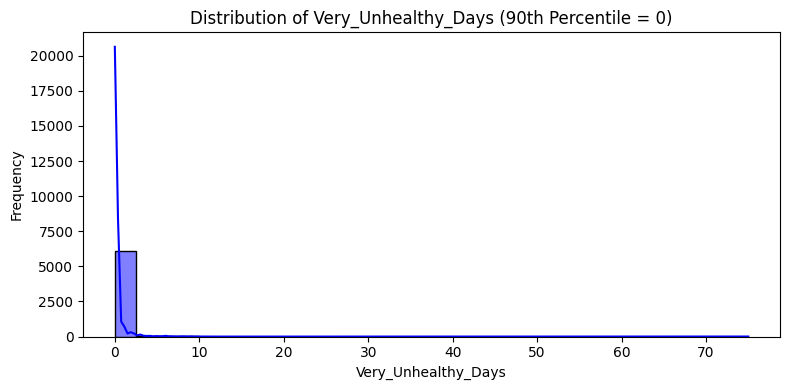

Variable 'Hazardous_Days' is heavily zero-inflated (90th percentile is 0)


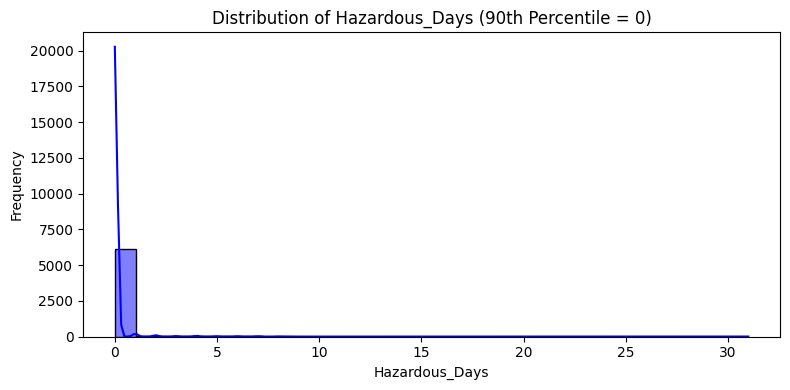

Variable 'Days_CO' is heavily zero-inflated (90th percentile is 0)


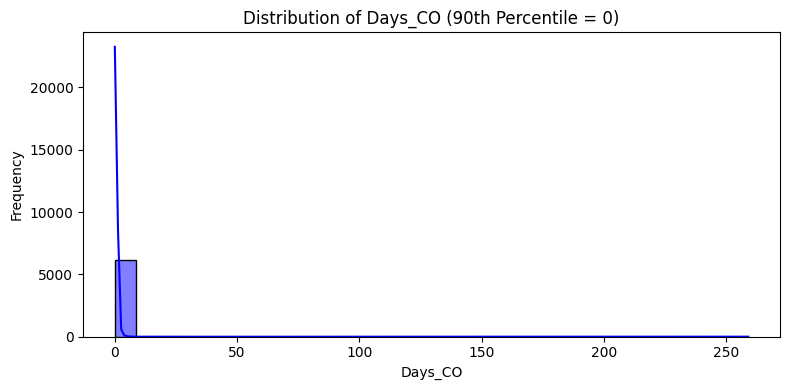

Variable 'Days_NO2' has a non-zero 90th percentile (3.0)
Variable 'Days_PM10' has a non-zero 90th percentile (10.0)


In [8]:
potential_zero_inflated_covariates = ['Unhealthy_Days', 'Very_Unhealthy_Days', 'Hazardous_Days', 'Days_CO', 'Days_NO2', 'Days_PM10']
zero_inflated_covariates = []

for col in potential_zero_inflated_covariates:
    p90_value = df[col].quantile(0.9)
    
    if p90_value == 0:
        print(f"Variable '{col}' is heavily zero-inflated (90th percentile is 0)")
        zero_inflated_covariates.append(col)
        # Plot
        plt.figure(figsize=(8, 4))
        sns.histplot(df[col], kde=True, color='blue', bins=30)
        plt.title(f"Distribution of {col} (90th Percentile = 0)")
        plt.xlabel(col)
        plt.ylabel("Frequency")
        plt.tight_layout()
        plt.show()
    else:
        print(f"Variable '{col}' has a non-zero 90th percentile ({p90_value})")

In [9]:
# Add binary terms
for col in zero_inflated_covariates:
    df[f'{col}_binary'] = (df[col] > 0).astype(int)
    df = df.drop(columns=[col])
df.head()

,State,County,Year,Unhealthy_for_Sensitive_Groups_Days,Unhealthy_Days,Max_AQI,90th_Percentile_AQI,Median_AQI,Days_NO2,Days_Ozone,Days_PM2_5,Days_PM10,Deaths,Population,Very_Unhealthy_Days_binary,Hazardous_Days_binary,Days_CO_binary
0,Alabama,Baldwin,2018,0,0,4.584967,54,37,0,194,76,0,5.420535,12.292356,0,0,0
1,Alabama,Clay,2018,0,0,4.234107,54,36,0,0,110,0,3.218876,9.493713,0,0,0
2,Alabama,Colbert,2018,0,0,4.543295,54,37,0,184,93,0,4.584967,10.910770,0,0,0
3,Alabama,DeKalb,2018,0,0,4.442651,54,36,0,286,64,0,4.718499,11.175857,0,0,0
4,Alabama,Elmore,2018,0,0,4.276666,49,33,0,222,0,0,4.543295,11.313108,0,0,0


### Correlation analysis

In this part we performed correlation analysis on the numeric predictors. Categorical vairables such as `County` and `State` will be excluded.

In [10]:
corr_df = df.drop(columns=["County", "State", "Deaths"]).dropna()
corr_matrix = corr_df.corr(numeric_only=True)

#### Correlation Matrix

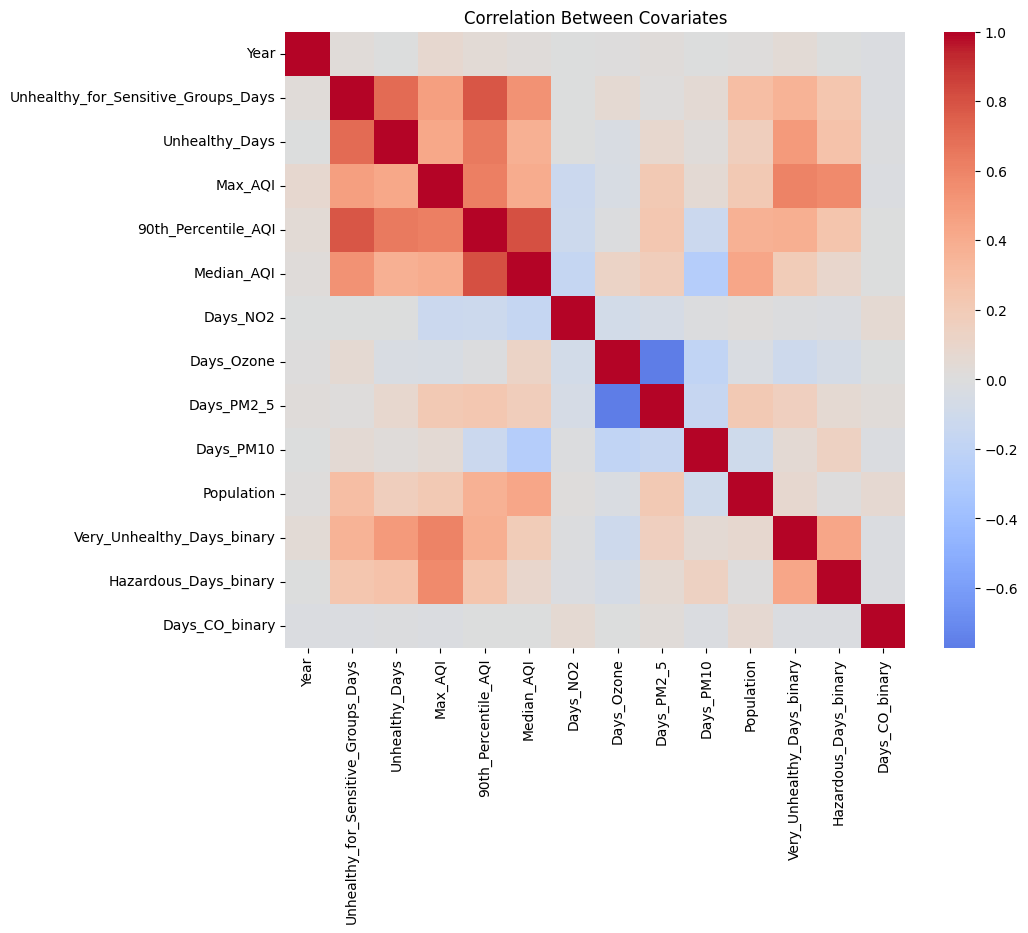

In [11]:
# Heatmap Visualization
plt.figure(figsize=(10,8))
sns.heatmap(
    corr_matrix,
    cmap="coolwarm",
    center=0
)
plt.title("Correlation Between Covariates")
plt.show()    

The heatmap visualizes the strength and direction of correlations among the numeric variables. Warmer colors(red) suggests positive correlation, while cooler colors(blue) represent negative correlations. 

From this heatmap, we observe several strong positive correlations between the AQI-related variables including Median AQI, 90th Percentile AQI, Max AQI, and the number of Moderate, Unhealthy, and Very Unhealthy Days. This is expected because they measure similar aspects of air pollution severity.  

At the same time, the variable Good Days appears to have negative correlations with many of the pollution indicators. This makes sense because counties that experience more days with good air quality generally have fewer days with higher pollution levels.

Based on this heatmap, we have evidence of multicollinearity and should drop columns with high correlation before fitting the regression model.

#### Variance Inflation Factor

In [12]:
def calc_vifs(df):
    df_const = add_constant(df)
    vif = pd.DataFrame()
    vif["variable"] = df_const.columns
    vif["VIF"] = [variance_inflation_factor(df_const.values, i) 
                  for i in range(df_const.shape[1])]
    return vif.set_index("variable").drop("const")

In [13]:
calc_vifs(corr_df)

,VIF
variable,
Year,1.012511
Unhealthy_for_Sensitive_Groups_Days,3.618568
Unhealthy_Days,2.517244
Max_AQI,3.077440
90th_Percentile_AQI,8.063186
Median_AQI,3.861993
Days_NO2,1.114963
Days_Ozone,4.085136
Days_PM2_5,4.284689


If we look at the VIF values, most of them appear to be reasonable. We will set a threshold of 5 and remove covariates with a VIF greater than 5.

In [14]:
remaining = corr_df.columns.tolist()

vif_df = calc_vifs(df[remaining].dropna())
to_drop = vif_df[vif_df["VIF"] > 5].index.tolist()
final_features = [v for v in remaining if v not in to_drop]

print(f"Dropped due to high VIF: {to_drop}")
print(f"Final Feature Set: {final_features}")

Dropped due to high VIF: ['90th_Percentile_AQI']
Final Feature Set: ['Year', 'Unhealthy_for_Sensitive_Groups_Days', 'Unhealthy_Days', 'Max_AQI', 'Median_AQI', 'Days_NO2', 'Days_Ozone', 'Days_PM2_5', 'Days_PM10', 'Population', 'Very_Unhealthy_Days_binary', 'Hazardous_Days_binary', 'Days_CO_binary']


With the reduced set of covariates, we can see that we now have a set of covariates with a resonable VIF value.

In [15]:
calc_vifs(df[final_features].dropna())

,VIF
variable,
Year,1.012491
Unhealthy_for_Sensitive_Groups_Days,2.679550
Unhealthy_Days,2.327676
Max_AQI,2.611946
Median_AQI,2.037232
Days_NO2,1.113808
Days_Ozone,4.047611
Days_PM2_5,4.275722
Days_PM10,1.508583


## Fitting Regression Model

### Processed Dataset
Split the dataset into a train set and test set for evaluating the model later

In [16]:
in_features = final_features
df = df[in_features + ["Deaths"]].dropna()
df.head()

,Year,Unhealthy_for_Sensitive_Groups_Days,Unhealthy_Days,Max_AQI,Median_AQI,Days_NO2,Days_Ozone,Days_PM2_5,Days_PM10,Population,Very_Unhealthy_Days_binary,Hazardous_Days_binary,Days_CO_binary,Deaths
0,2018,0,0,4.584967,37,0,194,76,0,12.292356,0,0,0,5.420535
1,2018,0,0,4.234107,36,0,0,110,0,9.493713,0,0,0,3.218876
2,2018,0,0,4.543295,37,0,184,93,0,10.910770,0,0,0,4.584967
3,2018,0,0,4.442651,36,0,286,64,0,11.175857,0,0,0,4.718499
4,2018,0,0,4.276666,33,0,222,0,0,11.313108,0,0,0,4.543295


In [17]:
def split_data_by_year(group_df, train_frac=0.8, random_state=42):
    train_set = group_df.sample(frac=train_frac, random_state=random_state)
    test_set = group_df.drop(train_set.index)
    return train_set, test_set

train_list = []
test_list = []

for year, group_df in df.groupby('Year'):
    train_subset, test_subset = split_data_by_year(group_df, train_frac=0.8, random_state=42)
    train_list.append(train_subset)
    test_list.append(test_subset)

train_df = pd.concat(train_list)
test_df = pd.concat(test_list)

print(f"Train Set Size: {len(train_df)}")
print(f"Test Set Size: {len(test_df)}")

Train Set Size: 4939
Test Set Size: 1235


### Mutliple Linear Regeression Model For Deaths

#### Backward Selection With BIC Criterion

In [18]:
selected_covariates = backward(train_df, criterion, response = 'Deaths')
selected_model = 'Deaths' + ' ~ ' + " + ".join(selected_covariates)
print(f"Selected Model: {selected_model}")

Criterion: 2781.5018350886003
Criterion: 2773.0809938517814
Criterion: 2765.604652770972
Criterion: 2758.9662701634616
Selected Model: Deaths ~ Days_PM10 + Very_Unhealthy_Days_binary + Year + Max_AQI + Unhealthy_for_Sensitive_Groups_Days + Hazardous_Days_binary + Days_NO2 + Median_AQI + Population


In [19]:
death_model = smf.ols(formula=selected_model, data=train_df).fit()
death_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                 Deaths   R-squared:                       0.920
Model:                            OLS   Adj. R-squared:                  0.920
Method:                 Least Squares   F-statistic:                     6289.
Date:                Sun, 15 Mar 2026   Prob (F-statistic):               0.00
Time:                        21:26:44   Log-Likelihood:                -1337.0
No. Observations:                4939   AIC:                             2694.
Df Residuals:                    4929   BIC:                             2759.
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
=======================================================================================================
                                          coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------
Intercept                              21.0440      4.575      4.599      0.000      12.074      30.014
Days_PM10                               0.0004      0.000      3.850      0.000       0.000       0.001
Very_Unhealthy_Days_binary              0.0932      0.023      3.989      0.000       0.047       0.139
Year                                   -0.0125      0.002     -5.511      0.000      -0.017      -0.008
Max_AQI                                -0.1620      0.016     -9.852      0.000      -0.194      -0.130
Unhealthy_for_Sensitive_Groups_Days    -0.0027      0.001     -3.755      0.000      -0.004      -0.001
Hazardous_Days_binary                   0.1115      0.037      2.983      0.003       0.038       0.185
Days_NO2                               -0.0012      0.000     -5.213      0.000      -0.002      -0.001
Median_AQI                              0.0061      0.001      9.405      0.000       0.005       0.007
Population                              0.8069      0.004    212.521      0.000       0.799       0.814
==============================================================================
Omnibus:                      240.996   Durbin-Watson:                   1.986
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              286.543
Skew:                          -0.528   Prob(JB):                     6.00e-63
Kurtosis:                       3.527   Cond. No.                     2.05e+06
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 2.05e+06. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

#### Interpretation of Regression Results

The regression results indicate that several air quality variables are statistically associated with respiratory disease deaths. In particular, the strongest predictors are variables that are linked to extreme air pollution events. The indicators **Very_Unhealthy_Days_binary** and **Hazardous_Days_binary** both have positive and statistically significant coefficients. This suggests that counties experiencing these extreme pollution levels tend to have higher numbers of respiratory-related deaths. These variables highlight that severe pollution is associated with noticeable increases in mortality.

In addition to these extreme pollution indicators, measures of baseline air pollution levels are also significant predictors. Both **Median_AQI** and **Days_PM10** have positive and statistically significant coefficients. This indicates that not only do extreme pollution events correspond with increased mortality, but the overall level of air pollution and particulate matter exposure also contribute to higher respiratory death counts.

Some variables show negative coefficients, including **Max_AQI** and **Days_NO2**. These negative signs likely reflect the presence of correlated pollution indicators already included in the model. Because the regression model already accounts for extreme pollution events through variables such as **Very_Unhealthy_Days_binary** and **Hazardous_Days_binary**, the coefficient for **Max_AQI** may capture the remaining variation after those extreme effects are controlled for. Similarly, NO₂ levels are often associated with dense urban areas, which may also have better healthcare infrastructure and emergency response systems. As a result, the negative coefficient for **Days_NO2** may reflect underlying differences across counties rather than a direct effect.

The **Population** variable has a strong positive coefficient and is highly statistically significant, which is expected since counties with larger populations generally experience more total deaths. On the other hand, the **Year** variable has a negative coefficient, suggesting a slight downward trend in respiratory mortality over the time period covered by the dataset.

Overall, the model demonstrates strong explanatory power with an R-squared of approximately 0.92, indicating that about 92% of the variation in respiratory disease deaths is explained by the predictors included in the model.

#### Validate Model Assumptions

In [20]:
residuals = death_model.resid

**Normality**

Residuals are approximately normally distributed with minor deviation in the tails, particularly at the lower extreme likely driven by counties with very low death counts. Based on the mild deviation from the line, our model doesn't materially violate the normality assumption.

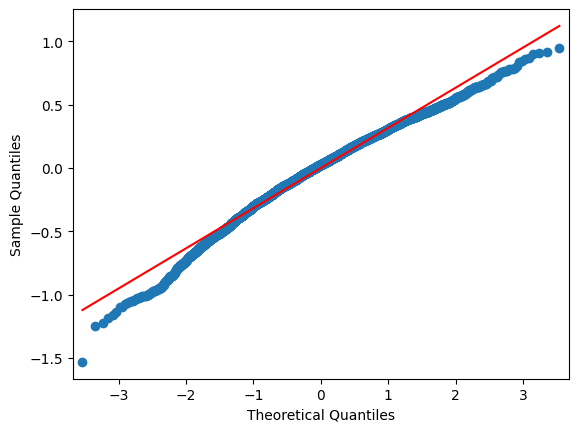

In [21]:
sm.qqplot(residuals, line='s')
plt.show()

**Independence**

Based on the ACF graph, the bars after lag 0 appear to be close to 0 indicating the independence assumption being satisfied.

(-0.1, 1.1)

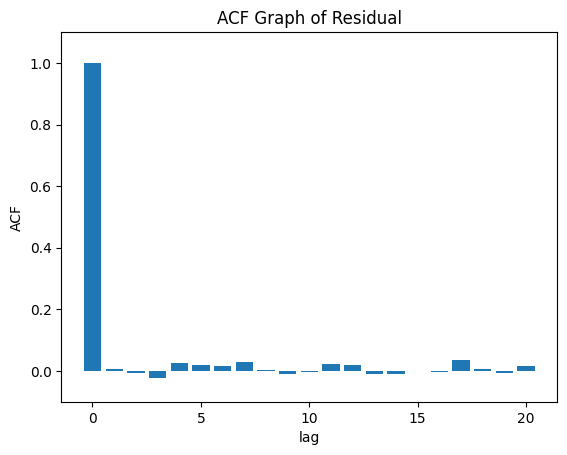

In [22]:
lags = 20
plt.bar(range(lags+1), acf(residuals, nlags=lags))
plt.title("ACF Graph of Residual")
plt.xlabel('lag')
plt.ylabel('ACF')
plt.ylim((-0.1, 1.1))

**Heteroscedasticity**

Based on the scatterplot of standardized residuals vs. fitted values, we see that there is a lot of scattered points around 0 indicating that the heteroscedasticity assumption is satisfied. We also see that the scatter plot is random indicating the linearity assumption being satisfied. The boundary that appears on the left is due to our log transform and is expected.

Text(0.5, 0, 'Fitted Values')

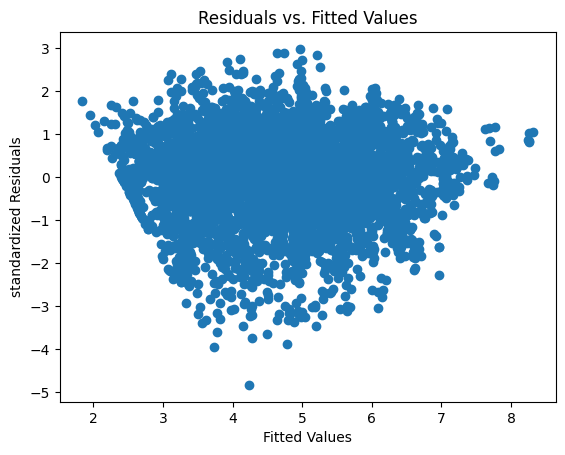

In [23]:
def standardize(X):
    return (X - X.mean()) / X.std()

plt.scatter(death_model.fittedvalues, standardize(residuals))
plt.title("Residuals vs. Fitted Values")
plt.ylabel("standardized Residuals")
plt.xlabel("Fitted Values")

#### Test Accuracy On Test Set

These are the log scaled metrics as the targets have been log scaled

In [24]:
def validate_model(model,test_df,target):
    targets = test_df[target]
    preds = model.predict(exog=test_df)
    mae = metrics.mean_absolute_error(targets, preds)
    mse = metrics.mean_squared_error(targets, preds)
    rmse = np.sqrt(mse) 
    r_squared = metrics.r2_score(targets, preds)
    print(f"Test Set MAE: {mae:.2f}")
    print(f"Test Set RMSE: {rmse:.2f}")
    print(f"Test Set R-squared: {r_squared:.2f}")

In [25]:
validate_model(death_model,test_df,"Deaths")

Test Set MAE: 0.25
Test Set RMSE: 0.32
Test Set R-squared: 0.92


#### Model Performance on Test Data
To evaluate the predictive performance of the regression model, we applied it to the test dataset. The model achieved a test MAE of 0.25 and a test RMSE of 0.32. Since the response variable was log scaled, our error metrics are in log scale. Given a MAE of 0.25 and $e^{0.25} \approx 1.28$, we can say the model has a 28.4% average error on the test set. For an RMSE of $0.32$ where $e^{0.32} \approx 1.38$, larger prediction errors correspond to deviations of roughly 38% on the original scale of respiratory deaths. The difference betweeen RMSE and MAE indicates that there are some counties where the prediction error was large. While the prediction errors on the test set are slightly elevated, we have evidence that our model was picking up the trends influencing respiratory deaths. In addition, the model obtained a test $R^2$ of 0.92, suggesting that it explains approximately 92% of the variation in respiratory disease deaths in the test data. Overall, these results indicate that the model maintains strong predictive performance on unseen data, suggesting that the selected predictors generalize well beyond the training dataset.

## Project Limitations

- The dataset does not include information about local environmental policies (e.g., emission regulations), so some confounding factors affecting air quality and respiratory mortality may not be captured in the models.

- The analysis covers a relatively short time period, which may limit the ability to observe long-term environmental and health trends. (lagged effects)

- Since the data only includes counties in the United States, the findings may not generalize to other regions with different environmental conditions.

- The year 2020 may introduce irregularities due to the COVID-19 pandemic, which could have affected both air pollution levels and mortality reporting.

## Next Steps
- Estimate other response variables
- Examining additional outcome measures
- Expanding the dataset to cover a longer timeframe
- Exploring modeling approaches that better handle **time-series data**.

## Related Work

Dockery DW, Pope CA 3rd, Xu X, Spengler JD, Ware JH, Fay ME, Ferris BG Jr, Speizer FE. An association between air pollution and mortality in six U.S. cities. N Engl J Med. 1993 Dec 9;329(24):1753-9. doi: 10.1056/NEJM199312093292401. PMID: 8179653.
- Uses U.S. based data
- 8111 adults — white subjects between ages 25-74
- Data from six cities
- Tracked across a follow up period of 14-16 years
- Uses Cox proportional hazards model
- Studies the association between air pollution and mortality
- Results suggest an association between higher mortality rate in more polluted cities

Di Q, Wang Y, Zanobetti A, Wang Y, Koutrakis P, Choirat C, Dominici F, Schwartz JD. Air Pollution and Mortality in the Medicare Population. N Engl J Med. 2017 Jun 29;376(26):2513-2522. doi: 10.1056/NEJMoa1702747. PMID: 28657878; PMCID: PMC5766848.
- Study of ~60 million Medicare beneficiaries in the U.S.
- Measure of PM2.5 and Ozone directly
- Uses a Cox proportional hazards model
- Controls for demographic and geographic levels
- Finds increased mortality risk associated with higher PM2.5 exposure


## Summary

-  Our analysis suggests that poorer air quality conditions are associated with higher levels of respiratory disease deaths.

- Several air quality indicators show measurable statistical relationships with respiratory health outcomes, suggesting that environmental conditions play a role in explaining differences across regions.

- However, the strength of these relationships varies and may also be influenced by other factors such as healthcare access, demographics, and local environmental policies.

- Overall, the findings highlight the potential role of air quality conditions in shaping respiratory health outcomes and demonstrate how statistical analysis can be used to study environmental health patterns.